# Table 8 — Basic Data Analysis

Patient-level AF plan data for all 58 patients from the 2025 paper.
Columns: PTV volume, prescription, tumor site, OAR, per-fraction overlap volumes, AF doses, upper-bound doses, and benefit (ccGy).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

df = pd.read_csv("table8.csv")

overlap_cols = [f"overlap_f{i}_cc" for i in range(1, 6)]
df["mean_overlap_cc"] = df[overlap_cols].mean(axis=1)
df["std_overlap_cc"] = df[overlap_cols].std(axis=1, ddof=1)

df.head()

,patient,ptv_volume_cc,prescription_gy,tumor_site,oar,overlap_planning_cc,overlap_f1_cc,overlap_f2_cc,overlap_f3_cc,overlap_f4_cc,...,af_dose_f5_gy,af_benefit_ccgy,ub_dose_f1_gy,ub_dose_f2_gy,ub_dose_f3_gy,ub_dose_f4_gy,ub_dose_f5_gy,ub_benefit_ccgy,mean_overlap_cc,std_overlap_cc
0,1,61.8,33,Pancreas,B,2.02,2.41,3.04,1.96,5.30,...,6,3.71,6,6,9,6,6,3.71,3.196,1.284730
1,2,124.5,33,Pancreas,B,6.19,10.97,4.91,7.65,5.73,...,6,6.35,6,9,6,6,6,6.35,7.026,2.420636
2,3,69.5,33,Pancreas,"B, S",9.08,19.79,6.02,9.45,19.59,...,6,22.42,6,9,6,6,6,22.42,13.494,6.119218
3,4,106.9,33,Pancreas,"D, B, S",15.07,19.81,16.12,22.63,18.09,...,6,0.98,6,6,6,6,9,8.93,18.418,2.912708
4,5,160.8,33,Pancreas,"D, B, S",17.15,18.68,18.35,28.56,21.37,...,9,-2.98,6,9,6,6,6,10.91,21.988,4.145331


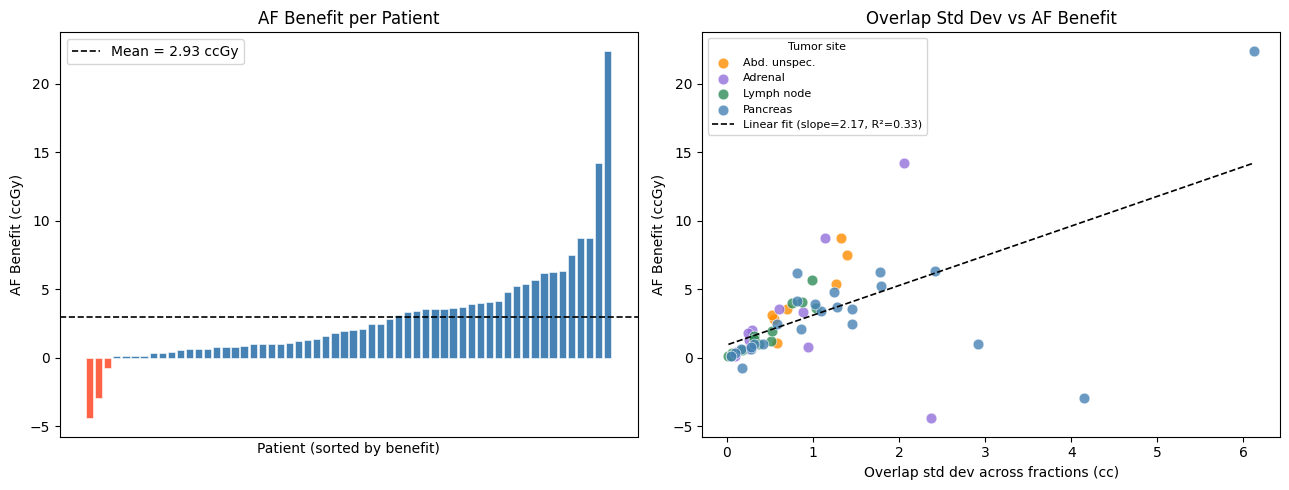

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: AF benefit per patient (sorted) ---
ax = axes[0]
sorted_df = df.sort_values("af_benefit_ccgy")
colors = ["tomato" if v < 0 else "steelblue" for v in sorted_df["af_benefit_ccgy"]]
ax.bar(range(len(sorted_df)), sorted_df["af_benefit_ccgy"], color=colors, edgecolor="white", linewidth=0.4)
ax.axhline(df["af_benefit_ccgy"].mean(), color="black", linestyle="--", linewidth=1.2, label=f"Mean = {df['af_benefit_ccgy'].mean():.2f} ccGy")
ax.set_xlabel("Patient (sorted by benefit)")
ax.set_ylabel("AF Benefit (ccGy)")
ax.set_title("AF Benefit per Patient")
ax.legend()
ax.xaxis.set_major_locator(ticker.NullLocator())

# --- Plot 2: Overlap std dev vs AF benefit ---
ax = axes[1]
site_colors = {"Pancreas": "steelblue", "Lymph node": "seagreen", "Abd. unspec.": "darkorange", "Adrenal": "mediumpurple"}
for site, grp in df.groupby("tumor_site"):
    ax.scatter(grp["std_overlap_cc"], grp["af_benefit_ccgy"],
               label=site, color=site_colors.get(site, "grey"), s=60, alpha=0.8, edgecolors="white", linewidths=0.5)

# Fit and plot a regression line, annotate with R²
m, b = np.polyfit(df["std_overlap_cc"], df["af_benefit_ccgy"], 1)
y_pred = m * df["std_overlap_cc"] + b
ss_res = ((df["af_benefit_ccgy"] - y_pred) ** 2).sum()
ss_tot = ((df["af_benefit_ccgy"] - df["af_benefit_ccgy"].mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot

x_range = np.linspace(df["std_overlap_cc"].min(), df["std_overlap_cc"].max(), 100)
ax.plot(x_range, m * x_range + b, color="black", linestyle="--", linewidth=1.2,
        label=f"Linear fit (slope={m:.2f}, R²={r2:.2f})")

ax.set_xlabel("Overlap std dev across fractions (cc)")
ax.set_ylabel("AF Benefit (ccGy)")
ax.set_title("Overlap Std Dev vs AF Benefit")
ax.legend(title="Tumor site", fontsize=8, title_fontsize=8)

fig.tight_layout()
plt.show()

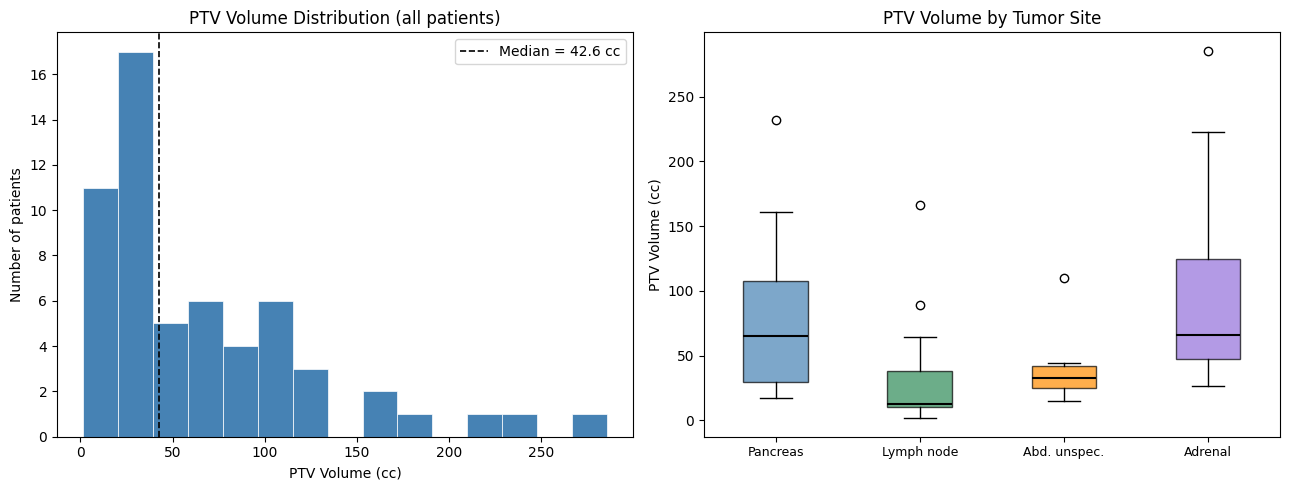

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Overall PTV volume distribution ---
ax = axes[0]
ax.hist(df["ptv_volume_cc"], bins=15, color="steelblue", edgecolor="white", linewidth=0.5)
ax.axvline(df["ptv_volume_cc"].median(), color="black", linestyle="--", linewidth=1.2,
           label=f"Median = {df['ptv_volume_cc'].median():.1f} cc")
ax.set_xlabel("PTV Volume (cc)")
ax.set_ylabel("Number of patients")
ax.set_title("PTV Volume Distribution (all patients)")
ax.legend()

# --- Plot 2: PTV volume distribution by tumor site ---
ax = axes[1]
site_order = ["Pancreas", "Lymph node", "Abd. unspec.", "Adrenal"]
site_colors_list = ["steelblue", "seagreen", "darkorange", "mediumpurple"]
data_by_site = [df.loc[df["tumor_site"] == s, "ptv_volume_cc"].values for s in site_order]
bp = ax.boxplot(data_by_site, patch_artist=True, medianprops=dict(color="black", linewidth=1.5))
for patch, color in zip(bp["boxes"], site_colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticks(range(1, len(site_order) + 1))
ax.set_xticklabels(site_order, fontsize=9)
ax.set_ylabel("PTV Volume (cc)")
ax.set_title("PTV Volume by Tumor Site")

fig.tight_layout()
plt.show()

Mean overlap volume by tumor site (cc):
               n  mean  median   std
tumor_site                          
Pancreas      24  4.79    2.94  5.87
Lymph node    13  1.15    0.69  1.24
Abd. unspec.   8  2.72    1.40  2.98
Adrenal       13  1.74    0.98  2.13

Kruskal-Wallis H=6.898, p=0.0752
→ No significant difference between sites (p≥0.05)


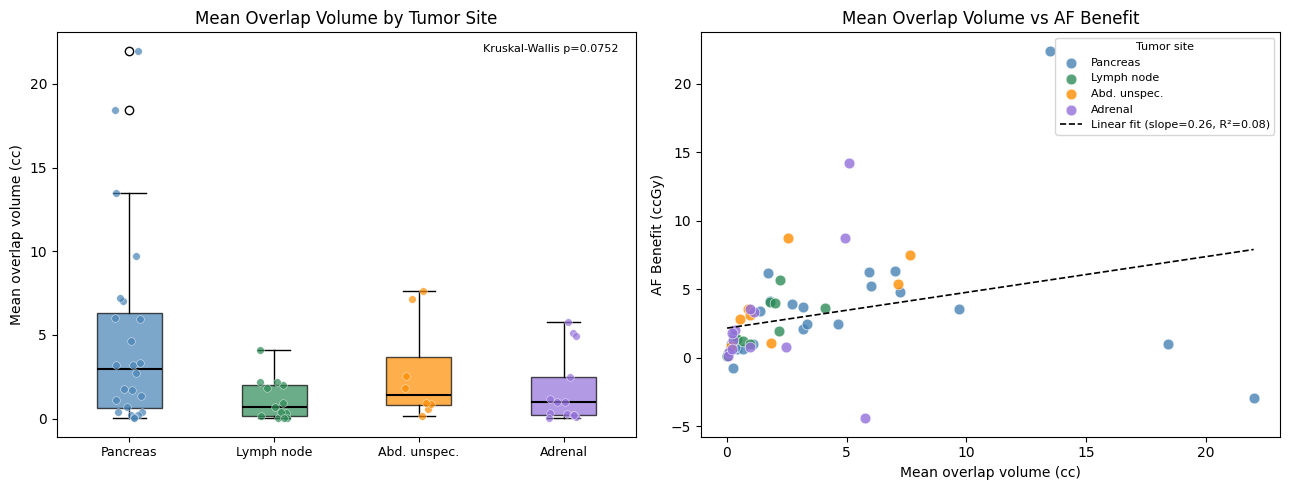

In [4]:
from scipy.stats import kruskal

site_order = ["Pancreas", "Lymph node", "Abd. unspec.", "Adrenal"]
site_colors_list = ["steelblue", "seagreen", "darkorange", "mediumpurple"]
groups = [df.loc[df["tumor_site"] == s, "mean_overlap_cc"].values for s in site_order]

# Summary statistics per site
summary = (
    df.groupby("tumor_site")["mean_overlap_cc"]
    .agg(n="count", mean="mean", median="median", std="std")
    .reindex(site_order)
    .round(2)
)
print("Mean overlap volume by tumor site (cc):")
print(summary.to_string())

# Kruskal-Wallis test (non-parametric, no normality assumption)
stat, p = kruskal(*groups)
print(f"\nKruskal-Wallis H={stat:.3f}, p={p:.4f}")
print("→ " + ("Significant difference between sites (p<0.05)" if p < 0.05 else "No significant difference between sites (p≥0.05)"))

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Boxplot of mean overlap by tumor site ---
ax = axes[0]
bp = ax.boxplot(groups, patch_artist=True, medianprops=dict(color="black", linewidth=1.5))
for patch, color in zip(bp["boxes"], site_colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for i, (grp, color) in enumerate(zip(groups, site_colors_list), start=1):
    ax.scatter(np.full(len(grp), i) + np.random.default_rng(0).uniform(-0.1, 0.1, len(grp)),
               grp, color=color, s=30, alpha=0.7, edgecolors="white", linewidths=0.4, zorder=3)
ax.set_xticks(range(1, len(site_order) + 1))
ax.set_xticklabels(site_order, fontsize=9)
ax.set_ylabel("Mean overlap volume (cc)")
ax.set_title("Mean Overlap Volume by Tumor Site")
ax.text(0.97, 0.97, f"Kruskal-Wallis p={p:.4f}", transform=ax.transAxes,
        ha="right", va="top", fontsize=8, color="black")

# --- Plot 2: Mean overlap vs AF benefit coloured by site ---
ax = axes[1]
for site, color in zip(site_order, site_colors_list):
    grp = df[df["tumor_site"] == site]
    ax.scatter(grp["mean_overlap_cc"], grp["af_benefit_ccgy"],
               label=site, color=color, s=60, alpha=0.8, edgecolors="white", linewidths=0.5)
m, b = np.polyfit(df["mean_overlap_cc"], df["af_benefit_ccgy"], 1)
y_pred = m * df["mean_overlap_cc"] + b
ss_res = ((df["af_benefit_ccgy"] - y_pred) ** 2).sum()
ss_tot = ((df["af_benefit_ccgy"] - df["af_benefit_ccgy"].mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot
x_range = np.linspace(df["mean_overlap_cc"].min(), df["mean_overlap_cc"].max(), 100)
ax.plot(x_range, m * x_range + b, color="black", linestyle="--", linewidth=1.2,
        label=f"Linear fit (slope={m:.2f}, R²={r2:.2f})")
ax.set_xlabel("Mean overlap volume (cc)")
ax.set_ylabel("AF Benefit (ccGy)")
ax.set_title("Mean Overlap Volume vs AF Benefit")
ax.legend(title="Tumor site", fontsize=8, title_fontsize=8)

fig.tight_layout()
plt.show()

Per-site range on the mu axis (cc):
               n   min   q25  median   q75    max
tumor_site                                       
Pancreas      24  0.03  0.61    2.94  6.28  21.99
Lymph node    13  0.02  0.14    0.69  2.02   4.09
Abd. unspec.   8  0.17  0.80    1.40  3.70   7.65
Adrenal       13  0.05  0.22    0.98  2.47   5.79

Pairwise [min, max] range overlap:
  Pancreas ∩ Lymph node: overlap=4.07 cc  (19% of Pancreas, 100% of Lymph node)
  Pancreas ∩ Abd. unspec.: overlap=7.48 cc  (34% of Pancreas, 100% of Abd. unspec.)
  Pancreas ∩ Adrenal: overlap=5.74 cc  (26% of Pancreas, 100% of Adrenal)
  Lymph node ∩ Abd. unspec.: overlap=3.92 cc  (96% of Lymph node, 52% of Abd. unspec.)
  Lymph node ∩ Adrenal: overlap=4.04 cc  (99% of Lymph node, 70% of Adrenal)
  Abd. unspec. ∩ Adrenal: overlap=5.62 cc  (75% of Abd. unspec., 98% of Adrenal)


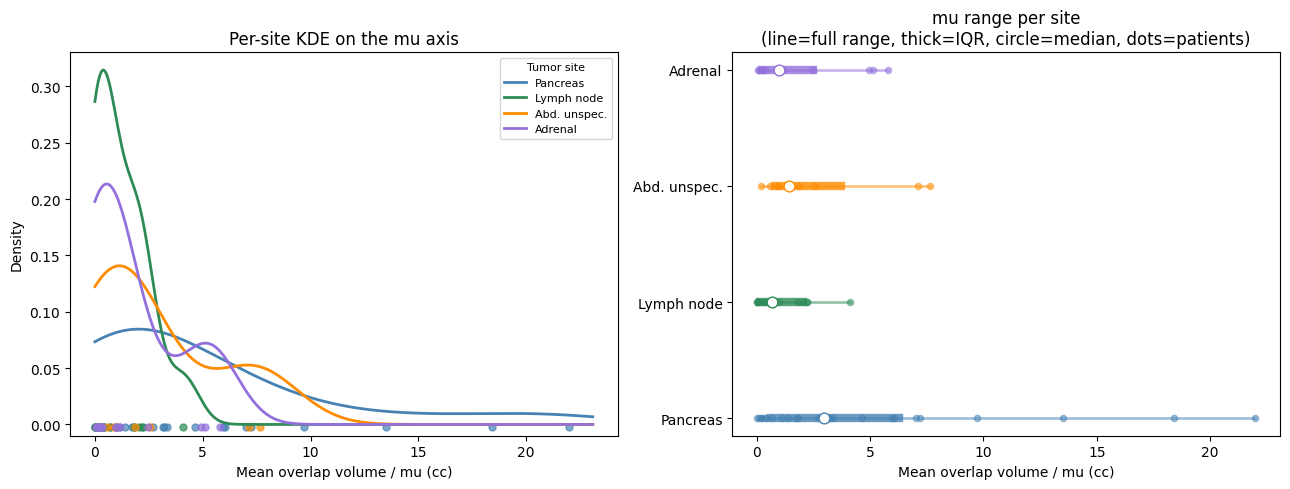

In [5]:
from scipy.stats import gaussian_kde

site_order = ["Pancreas", "Lymph node", "Abd. unspec.", "Adrenal"]
site_colors_list = ["steelblue", "seagreen", "darkorange", "mediumpurple"]

# --- Range table: where does each site live on the mu axis? ---
range_summary = (
    df.groupby("tumor_site")["mean_overlap_cc"]
    .agg(n="count", min="min", q25=lambda x: x.quantile(0.25),
         median="median", q75=lambda x: x.quantile(0.75), max="max")
    .reindex(site_order)
    .round(2)
)
print("Per-site range on the mu axis (cc):")
print(range_summary.to_string())

# Pairwise range overlap fraction: how much does site A's [min,max] overlap site B's?
print("\nPairwise [min, max] range overlap:")
ranges = {s: (df.loc[df["tumor_site"]==s, "mean_overlap_cc"].min(),
              df.loc[df["tumor_site"]==s, "mean_overlap_cc"].max()) for s in site_order}
for i, s1 in enumerate(site_order):
    for s2 in site_order[i+1:]:
        lo = max(ranges[s1][0], ranges[s2][0])
        hi = min(ranges[s1][1], ranges[s2][1])
        overlap_len = max(0, hi - lo)
        span1 = ranges[s1][1] - ranges[s1][0]
        span2 = ranges[s2][1] - ranges[s2][0]
        frac1 = overlap_len / span1 if span1 > 0 else 0
        frac2 = overlap_len / span2 if span2 > 0 else 0
        print(f"  {s1} ∩ {s2}: overlap={overlap_len:.2f} cc  "
              f"({frac1*100:.0f}% of {s1}, {frac2*100:.0f}% of {s2})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: KDE per site on the mu axis ---
ax = axes[0]
mu_range = np.linspace(0, df["mean_overlap_cc"].max() * 1.05, 300)
for site, color in zip(site_order, site_colors_list):
    vals = df.loc[df["tumor_site"] == site, "mean_overlap_cc"].values
    if len(vals) >= 3:
        kde = gaussian_kde(vals, bw_method="scott")
        ax.plot(mu_range, kde(mu_range), color=color, linewidth=2, label=site)
    ax.scatter(vals, np.zeros(len(vals)) - 0.002, color=color, s=25, alpha=0.7, clip_on=False)
ax.set_xlabel("Mean overlap volume / mu (cc)")
ax.set_ylabel("Density")
ax.set_title("Per-site KDE on the mu axis")
ax.legend(title="Tumor site", fontsize=8, title_fontsize=8)
ax.set_ylim(bottom=-0.01)

# --- Plot 2: Horizontal range bars per site (min–max with IQR) ---
ax = axes[1]
for i, (site, color) in enumerate(zip(site_order, site_colors_list)):
    vals = df.loc[df["tumor_site"] == site, "mean_overlap_cc"].values
    mn, q25, med, q75, mx = vals.min(), np.quantile(vals, 0.25), np.median(vals), np.quantile(vals, 0.75), vals.max()
    ax.plot([mn, mx], [i, i], color=color, linewidth=2, alpha=0.5)          # full range
    ax.plot([q25, q75], [i, i], color=color, linewidth=6, alpha=0.8)        # IQR
    ax.scatter([med], [i], color="white", edgecolors=color, s=60, zorder=3) # median
    ax.scatter(vals, np.full(len(vals), i), color=color, s=20, alpha=0.5, zorder=2)
ax.set_yticks(range(len(site_order)))
ax.set_yticklabels(site_order)
ax.set_xlabel("Mean overlap volume / mu (cc)")
ax.set_title("mu range per site\n(line=full range, thick=IQR, circle=median, dots=patients)")

fig.tight_layout()
plt.show()

## Note: "Benefit" in Table 8 is the Upper Bound

The paper reports a mean benefit of 2.93 ccGy across the 58 patients. This matches the **upper bound** benefit computed by our codebase (mean ~3.01 ccGy), not the AF algorithm's realised benefit (mean ~1.28 ccGy on master, ~1.38 ccGy with the belief-state DP).

The upper bound is the theoretical maximum achievable with perfect foreknowledge of all future overlaps. The paper does not explicitly label this column as "upper bound", but the numbers confirm it.